Data shape: (100000, 14)
Training set shape: (80000, 12)
Testing set shape: (20000, 12)

=== Training Base LightGBM Model ===
Training until validation scores don't improve for 50 rounds
[10]	valid_0's rmse: 0.642177
[20]	valid_0's rmse: 0.430378
[30]	valid_0's rmse: 0.307684
[40]	valid_0's rmse: 0.246224
[50]	valid_0's rmse: 0.2182
[60]	valid_0's rmse: 0.206736
[70]	valid_0's rmse: 0.201872
[80]	valid_0's rmse: 0.200028
[90]	valid_0's rmse: 0.199095
[100]	valid_0's rmse: 0.198808
[110]	valid_0's rmse: 0.198873
[120]	valid_0's rmse: 0.198858
[130]	valid_0's rmse: 0.198765
[140]	valid_0's rmse: 0.198799
[150]	valid_0's rmse: 0.198866
[160]	valid_0's rmse: 0.198816
[170]	valid_0's rmse: 0.198831
[180]	valid_0's rmse: 0.199004
[190]	valid_0's rmse: 0.199112
Early stopping, best iteration is:
[142]	valid_0's rmse: 0.198752
Base model training time: 0.44 seconds
--- Base LightGBM Model Performance Metrics ---
RMSE: 0.20
R² Score: 0.9606
MAPE: 1509.69%
Prediction Accuracy: -1409.69%


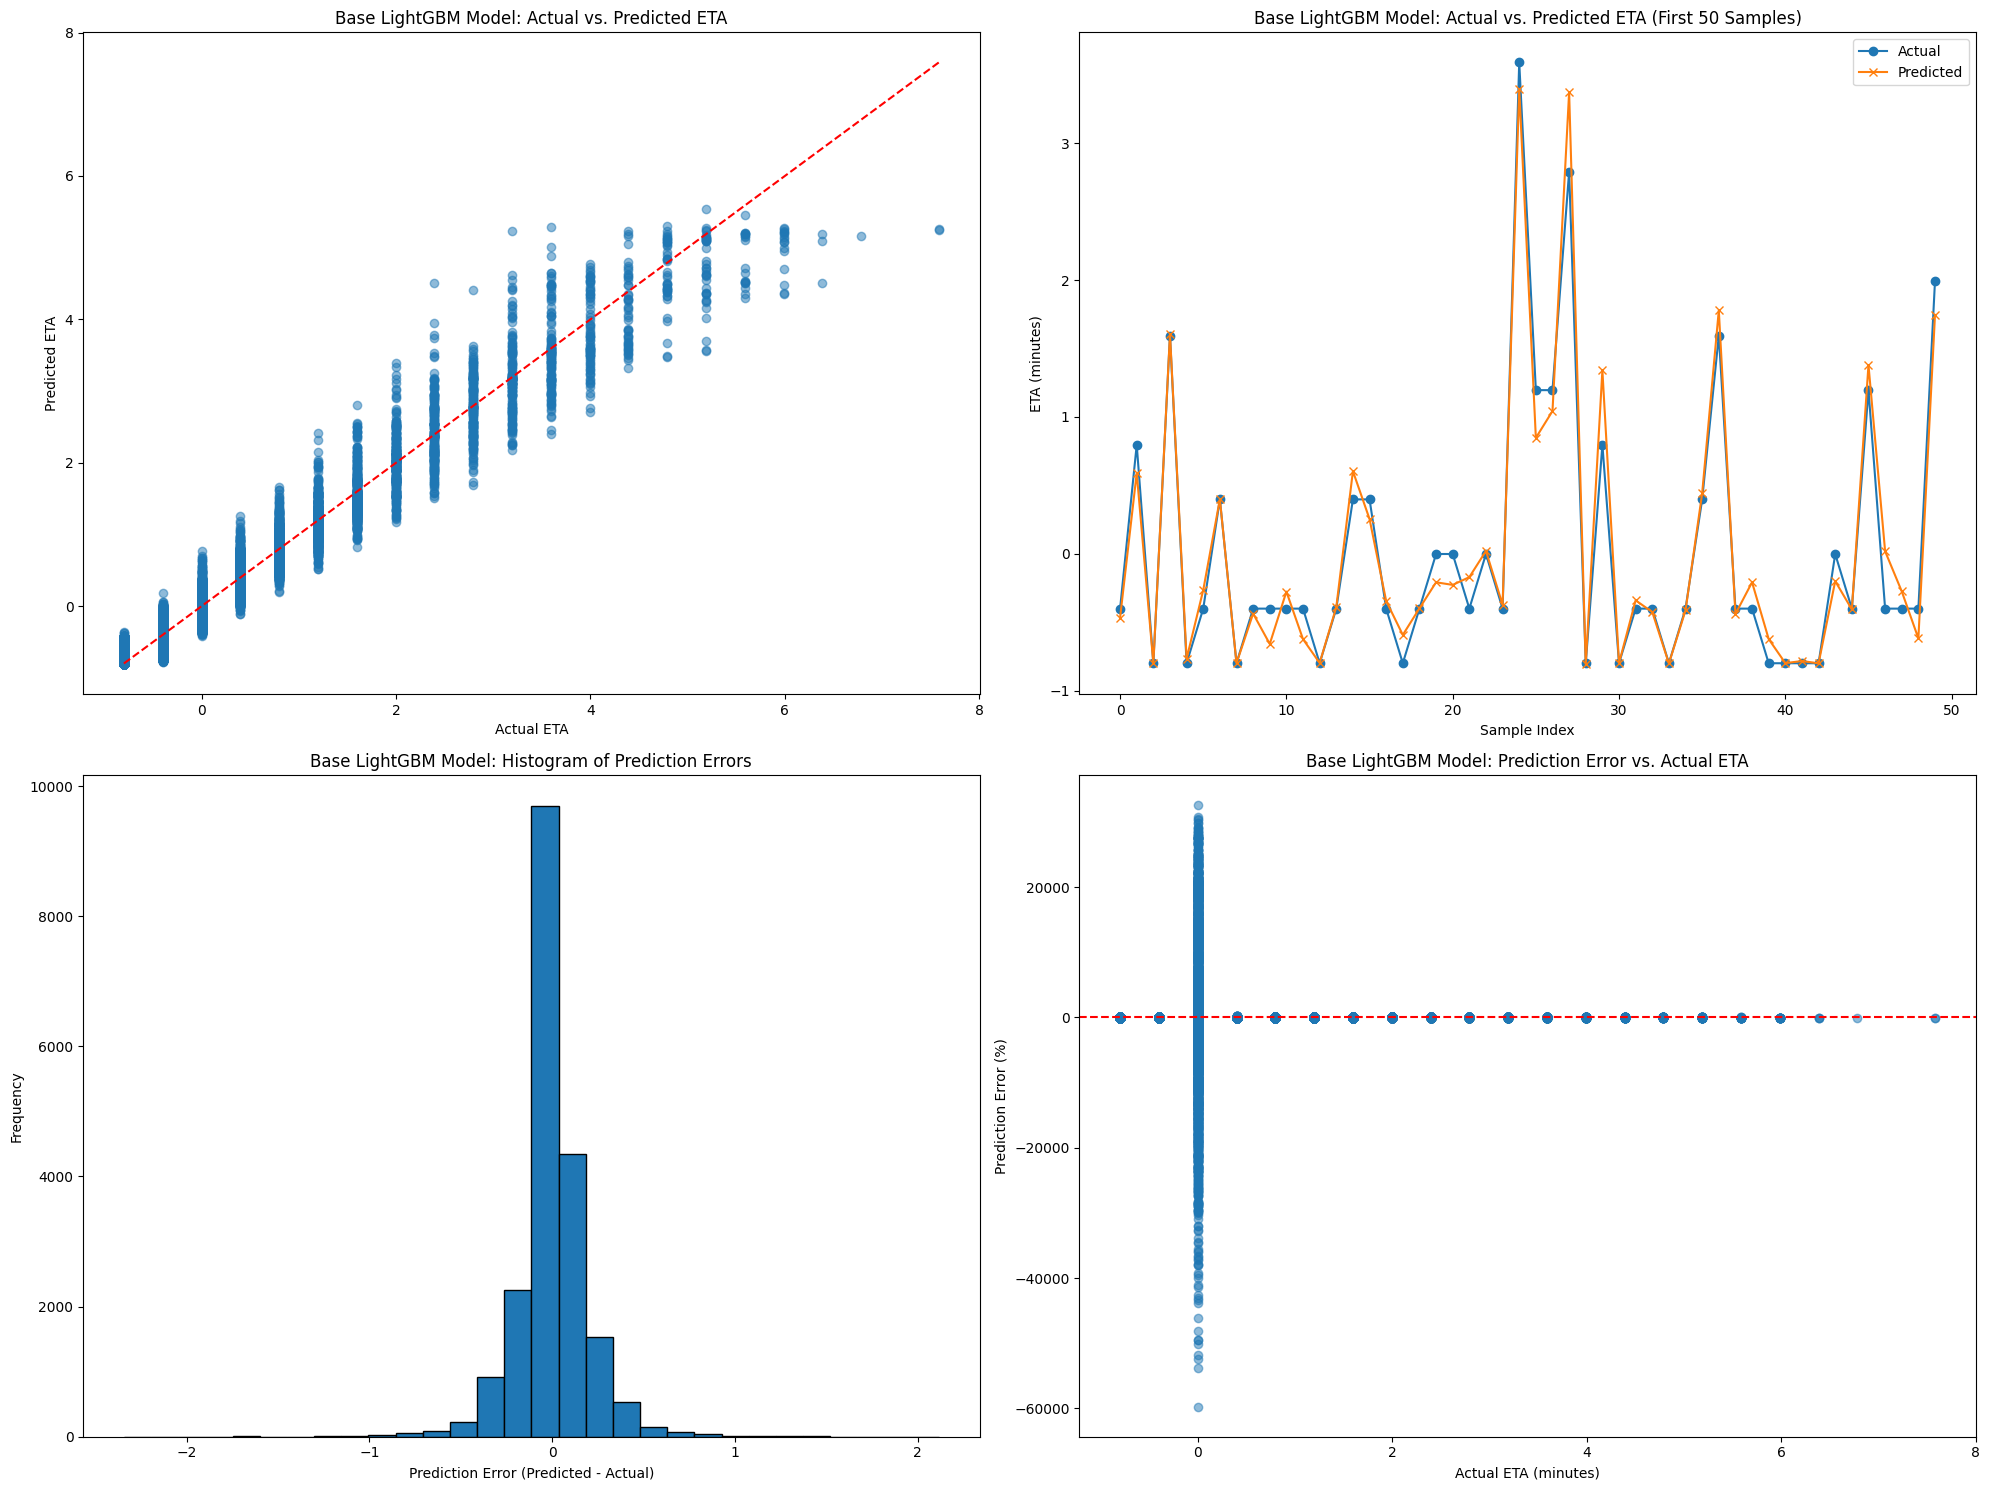


=== Performing Hyperparameter Tuning ===
Fitting 3 folds for each of 50 candidates, totalling 150 fits


KeyboardInterrupt: 

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv('bus_eta_standard_scaled.csv')

print("Data shape:", df.shape)

# Selecting features and target variable
X = df.drop(columns=['timestamp', 'eta_minutes'])  # Features
y = df['eta_minutes']  # Target

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# Function to evaluate and visualize model performance
def evaluate_model(model, X_test, y_test, model_name):
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    accuracy = 100 - mape
    
    print(f"--- {model_name} Performance Metrics ---")
    print(f'RMSE: {rmse:.2f}')
    print(f'R² Score: {r2:.4f}')
    print(f"MAPE: {mape:.2f}%")
    print(f"Prediction Accuracy: {accuracy:.2f}%")
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(20, 15))
    
    # Scatter plot of actual vs predicted
    axes[0, 0].scatter(y_test, y_pred, alpha=0.5)
    axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', linestyle='--')
    axes[0, 0].set_xlabel("Actual ETA")
    axes[0, 0].set_ylabel("Predicted ETA")
    axes[0, 0].set_title(f"{model_name}: Actual vs. Predicted ETA")
    
    # Line plot of first 50 samples
    axes[0, 1].plot(y_test.values[:50], label="Actual", marker='o')
    axes[0, 1].plot(y_pred[:50], label="Predicted", marker='x')
    axes[0, 1].set_xlabel("Sample Index")
    axes[0, 1].set_ylabel("ETA (minutes)")
    axes[0, 1].set_title(f"{model_name}: Actual vs. Predicted ETA (First 50 Samples)")
    axes[0, 1].legend()
    
    # Histogram of errors
    errors = y_pred - y_test
    axes[1, 0].hist(errors, bins=30, edgecolor='black')
    axes[1, 0].set_xlabel("Prediction Error (Predicted - Actual)")
    axes[1, 0].set_ylabel("Frequency")
    axes[1, 0].set_title(f"{model_name}: Histogram of Prediction Errors")
    
    # Percentage error vs actual
    percentage_error = 100 * (y_pred - y_test) / y_test
    axes[1, 1].scatter(y_test, percentage_error, alpha=0.5)
    axes[1, 1].axhline(y=0, color='r', linestyle='--')
    axes[1, 1].set_xlabel("Actual ETA (minutes)")
    axes[1, 1].set_ylabel("Prediction Error (%)")
    axes[1, 1].set_title(f"{model_name}: Prediction Error vs. Actual ETA")
    
    plt.tight_layout()
    plt.show()
    
    return {
        'rmse': rmse,
        'r2': r2,
        'mape': mape,
        'accuracy': accuracy,
        'predictions': y_pred
    }

# Step 1: Create a basic LightGBM model (CPU only)
print("\n=== Training Base LightGBM Model ===")

# Create LGB datasets for faster training
lgb_train = lgb.Dataset(X_train, y_train)
lgb_eval = lgb.Dataset(X_test, y_test, reference=lgb_train)

# Base parameters - no GPU parameters
base_params = {
    'boosting_type': 'gbdt',
    'objective': 'regression',
    'metric': 'rmse',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
}

# Train the base model and measure time
start_time = time.time()
base_model = lgb.train(
    base_params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_eval],
    callbacks=[
        lgb.callback.early_stopping(stopping_rounds=50, verbose=True),
        lgb.callback.log_evaluation(period=10)
    ]
)
base_training_time = time.time() - start_time
print(f"Base model training time: {base_training_time:.2f} seconds")

# Evaluate the base model
base_results = evaluate_model(base_model, X_test, y_test, "Base LightGBM Model")

# Step 2: Hyperparameter tuning with RandomizedSearchCV
print("\n=== Performing Hyperparameter Tuning ===")

# Create the LightGBM model for tuning (CPU only)
lgb_model = lgb.LGBMRegressor(verbose=-1)

# Define the hyperparameter search space
param_dist = {
    'num_leaves': [15, 31, 63, 127, 255],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 500, 1000, 1500],
    'max_depth': [-1, 5, 10, 15, 20],
    'min_child_samples': [5, 10, 20, 50, 100],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1, 2],
    'reg_lambda': [0, 0.1, 0.5, 1, 2]
}

# RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_dist,
    n_iter=50,  # Increased number of parameter settings sampled
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1  # Use all available cores
)

# Perform the hyperparameter tuning
start_time = time.time()
random_search.fit(X_train, y_train)
tuning_time = time.time() - start_time

print(f"\nHyperparameter tuning completed in {tuning_time:.2f} seconds")
print(f"Best parameters: {random_search.best_params_}")
print(f"Best RMSE: {np.sqrt(-random_search.best_score_):.4f}")

# Train the optimized model with the best parameters
print("\n=== Training Optimized LightGBM Model ===")

# Get the best parameters (no GPU parameters)
best_params = random_search.best_params_.copy()
best_params['objective'] = 'regression'
best_params['metric'] = 'rmse'
best_params['verbose'] = -1

# Extract n_estimators and remove it from params (it's used differently in lgb.train)
n_estimators = best_params.pop('n_estimators')

# Train the optimized model
start_time = time.time()
optimized_model = lgb.train(
    best_params,
    lgb_train,
    num_boost_round=n_estimators,
    valid_sets=[lgb_eval],
    callbacks=[
        lgb.callback.early_stopping(stopping_rounds=50, verbose=True),
        lgb.callback.log_evaluation(period=10)
    ]
)
optimized_training_time = time.time() - start_time
print(f"Optimized model training time: {optimized_training_time:.2f} seconds")

# Evaluate the optimized model
optimized_results = evaluate_model(optimized_model, X_test, y_test, "Optimized LightGBM Model")

# Compare the performance of base and optimized models
print("\n=== Performance Comparison ===")
print(f"{'Metric':<20} {'Base Model':<15} {'Optimized Model':<15} {'Improvement':<15}")
print("-" * 65)
metrics = [
    ('RMSE', base_results['rmse'], optimized_results['rmse'], 
     f"{(base_results['rmse'] - optimized_results['rmse'])/base_results['rmse']*100:.2f}%"),
    ('R² Score', base_results['r2'], optimized_results['r2'], 
     f"{(optimized_results['r2'] - base_results['r2'])/abs(base_results['r2'])*100:.2f}%"),
    ('MAPE', base_results['mape'], optimized_results['mape'], 
     f"{(base_results['mape'] - optimized_results['mape'])/base_results['mape']*100:.2f}%"),
    ('Accuracy', base_results['accuracy'], optimized_results['accuracy'], 
     f"{(optimized_results['accuracy'] - base_results['accuracy'])/base_results['accuracy']*100:.2f}%"),
    ('Training Time (s)', base_training_time, optimized_training_time, 
     f"{(base_training_time - optimized_training_time)/base_training_time*100:.2f}%")
]

for metric, base, optimized, improvement in metrics:
    print(f"{metric:<20} {base:<15.4f} {optimized:<15.4f} {improvement:<15}")

# Feature importance plot
plt.figure(figsize=(12, 8))
lgb.plot_importance(optimized_model, max_num_features=20)
plt.title('Feature Importance (Optimized Model)')
plt.tight_layout()
plt.show()

# Save the optimized model
optimized_model.save_model('lightgbm_optimized_model1.txt')
print("Optimized model saved as 'lightgbm_optimized_model1.txt'")